# Проект: Прогнозирование температуры звезды

### Описание проекта

Прогнозирование температуры звезды

Вам пришла задача от обсерватории «Небо на ладони»: придумать, как с помощью нейросети определять температуру на поверхности обнаруженных звёзд. Обычно для расчёта температуры учёные пользуются следующими методами:
- Закон смещения Вина.
- Закон Стефана-Больцмана.
- Спектральный анализ.

Каждый из них имеет плюсы и минусы. Обсерватория хочет внедрить технологии машинного обучения для предсказания температуры звёзд, надеясь, что этот метод будет наиболее точным и удобным.

В базе обсерватории есть характеристики уже изученных 240 звёзд.

### Цель проекта

Необходимо разработать нейронную сеть, которая поможет предсказывать абсолютную температуру на поверхности звезды.

### Задачи проекта

1) Создайте функцию для обучения нейронной сети.
2) Проведите обучение модели.
3) Постройте график «Факт — Прогноз», где по горизонтальной оси будут отложены условные номера звёзд, а по вертикальной — температура в Кельвинах.

4) Создайте решение с перебором параметров нейросети. Список параметров для перебора должен включать как минимум «dropout» и «размер батча». Архитектуру нейронной сети: количество слоёв, нейронов, вид функции активации — оставьте как в Baseline, чтобы сравнить результат.
5) Проведите обучение нейронной сети. Выведите метрику RMSE и график «Факт — прогноз». Метрика RMSE не должна превышать 4500.
6) Сделайте вывод. Желательно оформить его в виде таблицы или графика.

### Описание данных

Признаки
- Относительная светимость L/Lo — светимость звезды относительно Солнца.
- Относительный радиус R/Ro — радиус звезды относительно радиуса Солнца.
- Абсолютная звёздная величина Mv — физическая величина, характеризующая блеск звезды.
- Звёздный цвет (white, red, blue, yellow, yellow-orange и др.) — цвет звезды, который определяют на основе спектрального анализа.
- Тип звезды.


Целевой признак
- Абсолютная температура T(K) — температура на поверхности звезды в Кельвинах.

## Импорт библиотек

In [2]:
!pip install category_encoders -q

In [3]:
!pip install torch -q

In [4]:
!pip install phik -q

In [5]:
!pip install -U scikit-learn -q

In [6]:
!pip install imblearn -q

In [7]:
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

import phik

from sklearn.model_selection import train_test_split

from sklearn.metrics import root_mean_squared_error


from math import ceil

from numpy.random import RandomState
from numpy import mean
from numpy import std

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import optuna

# загружаем класс pipeline
from imblearn.pipeline import Pipeline

# загружаем классы для подготовки данных
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer

# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer



In [8]:
n_ = 42

RANDOM_STATE= n_
state = RandomState(n_)
TEST_SIZE= 0.2
plt.rcParams["figure.figsize"] = (12,6)

random.seed(n_)
np.random.seed(n_)
torch.manual_seed(n_)
torch.use_deterministic_algorithms(True)

## Пользовательские функции

In [9]:
def df_hist(df, bins=20, id=0):

    # Удаление столбца id из датафрейма для создания графиков
    if id:
        df = df.drop(columns=['id'])

    # Определение целочисленных столбцов 
    count_col = df.select_dtypes('number')
    count_col = count_col.columns[count_col.nunique() < 11]

    # Создание гистограммы и boxplot для непрерывных данных
    for col in df.select_dtypes('number').drop(columns=count_col):
        fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,6))
        df[col].hist(bins=bins, ax=ax1)
        ax1.set_title(f'Гистограмма по столбцу "{col}"')
        ax1.set_xlabel(col)
        ax1.set_ylabel('Количество')
        df.boxplot(column=col, ax=ax2, vert=False)
        ax2.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax2.set_title(f'Ящик с усами по столбцу "{col}"')
        plt.xlabel(col)
        plt.show();

    # Создание countplot для целочесленных данных
    for col in df[count_col]:
        sns.countplot(data=df, x=col)
        plt.grid(True)
        plt.ylabel('Количество')
        plt.xlabel(col)
        plt.title(f'Диаграмма по столбцу "{col}"')
        plt.show();

    # Создание countplot для категориальных данных
    for col in df.select_dtypes('object'):
        sns.countplot(data=df, x=col)
        if df[col].nunique() > 3:
            plt.xticks(rotation=90)
        plt.grid(True)
        plt.ylabel('Количество')
        plt.xlabel(col)
        plt.title(f'Диаграмма по столбцу "{col}"')
        plt.show();

In [10]:
def df_hist_dict(df_dict, bins=20, id=0):
	for key, df in df_dict.items():
		# Удаление столбца id из датафрейма для создания графиков
		if id:
			df = df.drop(columns=['id'])
		# df = df.round(2)

		# Определение целочисленных столбцов 
		count_col = df.select_dtypes('number')
		count_col = count_col.columns[count_col.nunique() < 12]

		# Создание гистограммы и boxplot для непрерывных данных
		for col in df.select_dtypes('number').drop(columns=count_col):
			fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,6))
			df[col].hist(bins=bins, ax=ax1)
			ax1.set_title(f'Датасет {key} \nГистограмма по столбцу "{col}"')
			ax1.set_xlabel(col)
			ax1.set_ylabel('Количество')
			df.boxplot(column=col, ax=ax2, vert=False)
			ax2.tick_params(axis='y', which='both', left=False, labelleft=False)
			ax2.set_title(f'Датасет {key} \nЯщик с усами по столбцу "{col}"')
			plt.xlabel(col)
			plt.show();

		# Создание countplot для целочесленных данных
		for col in df[count_col]:
			sns.countplot(data=df.round(2), x=col)
			plt.grid(True)
			plt.ylabel('Количество')
			plt.xlabel(col)
			plt.title(f'Датасет {key} \nДиаграмма по столбцу "{col}"')
			plt.show();

		# Создание countplot для категориальных данных
		for col in df.select_dtypes('object'):
			sns.countplot(data=df, x=col)
			if df[col].nunique() > 3:
				plt.xticks(rotation=90)
			plt.grid(True)
			plt.ylabel('Количество')
			plt.xlabel(col)
			plt.title(f'Датасет {key} \nДиаграмма по столбцу "{col}"')
			plt.show();

		# Создание countplot для булевых данных
		for col in df.select_dtypes('bool'):
			sns.countplot(data=df, x=col)
			if df[col].nunique() > 3:
				plt.xticks(rotation=90)
			plt.grid(True)
			plt.ylabel('Количество')
			plt.xlabel(col)
			plt.title(f'Датасет {key} \nДиаграмма по столбцу "{col}"')
			plt.show();

In [11]:
def df_info(dict_df):
    for key, value in dict_df.items():
        print(key)
        value.info()
        display(value.head(5))
        print('----------------------------------------------------')
        print('\n')

In [12]:
def df_pred(dict_df):
    for key, value in dict_df.items():
        print(key)
        print('Удалено явных дубликатов', value.duplicated().sum())
        dict_df[key] = dict_df[key].drop_duplicates()
        print('Максимум пропусков', value.isna().sum().max())
        print('----------------------------------------------------')
        print('\n')

In [13]:
def df_value(dict_df, obj=True):
    for key, value in dict_df.items():
        print(f'Датафрейм: {key}')
        print('\n')
        for col in (value.select_dtypes('object') if obj else value).columns:
            display(value[col].value_counts())
            print('\n')
        print('----------------------------------------------------')
        print('\n')

In [14]:
def df_corr(dict_df, continuous_features=None):
    for df_k, df_v in dict_df.items():
        if continuous_features is None:
            continuous_features = df_v.select_dtypes('number').columns
        if len(df_v.columns) > 1:
            plt.figure(figsize=(15,15));
            ax = sns.heatmap(df_v.phik_matrix(interval_cols=continuous_features), annot=True, fmt='.2f', cmap='coolwarm');
            ax.set(xlabel="", ylabel="", title=f'Корреляционная матрица датафрейма {df_k}')
            plt.show();

In [ ]:
def plot_bars(preds, y, size=10):
	best_preds_np = preds.detach().cpu().numpy()
	plot_df = pd.DataFrame(best_preds_np, columns=['predictions'])
	plot_df['facts'] = y
	plot_df['Номер'] = range(1, len(y) + 1)
	print(f'RMSE = {root_mean_squared_error(y, best_preds_np)}')
	display(plot_df.head(5))

	ax = plot_df[:size].plot(x='Номер', 
					y='facts', 
					kind='bar', 
					color='#ff7f0e',   
					alpha=1,
					width=0.8,          
					label='facts',
					ylabel='Temperature',
					grid=True)

	plot_df[:size].plot(x='Номер', 
				y='predictions', 
				kind='bar', 
				color='#1f77b4',   
				alpha=1,          
				label='predictions',
				grid=True,
				ax=ax)              

	ax.legend()

## Загрузка данных

In [16]:
try:
    stars = pd.read_csv('6_class.csv', 
                        index_col='Unnamed: 0'
                        # parse_dates=['DateCrawled',
                        #              'DateCreated',
                        #              'LastSeen']
                        ).sort_index()
except:
    stars = pd.read_csv('/datasets/6_class.csv', 
                        # index_col='id'
                        ).sort_index()

In [17]:
try:
    stars.drop(columns='Unnamed: 0', inplace=True)
except:
    print('Данного столбца не существует')

Данного столбца не существует


In [18]:
try:
    stars.drop(columns='Unnamed: 0.1', inplace=True)
except:
    print('Данного столбца не существует')

In [19]:
list_1 = ('stars')
dict_1 = {'stars':stars}

In [20]:
df_info(dict_1)

stars
<class 'pandas.core.frame.DataFrame'>
Int64Index: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
dtypes: float64(3), int64(2), object(1)
memory usage: 13.1+ KB


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color
0,3068,0.002400,0.1700,16.12,0,Red
1,3042,0.000500,0.1542,16.60,0,Red
2,2600,0.000300,0.1020,18.70,0,Red
3,2800,0.000200,0.1600,16.65,0,Red
4,1939,0.000138,0.1030,20.06,0,Red


----------------------------------------------------




### Промежуточный вывод

Датасет загружен, пропущенные значения отсутствуют


## Предобработка данных

In [21]:
df_pred(dict_1)

stars
Удалено явных дубликатов 0
Максимум пропусков 0
----------------------------------------------------




In [22]:
df_value(dict_1)

Датафрейм: stars




Red                   112
Blue                   55
Blue-white             26
Blue White             10
yellow-white            8
White                   7
white                   3
Blue white              3
Yellowish White         3
Orange                  2
yellowish               2
Whitish                 2
Yellowish               1
Blue                    1
Pale yellow orange      1
Orange-Red              1
White-Yellow            1
Blue white              1
Blue-White              1
Name: Star color, dtype: int64



----------------------------------------------------




In [23]:
dict_1['stars']['Star color'] = dict_1['stars']['Star color'].str.rstrip().str.replace(' ','-').str.lower()

In [24]:
dict_1['stars']['Star color'] = \
dict_1['stars']['Star color'].str.rstrip().str.replace('yellowish-white','yellow-white')\
                                          .str.replace('yellowish','yellow')\
                                          .str.replace('whitish','white')\
                                          .str.replace('white-yellow','yellow-white')\
                                          .str.replace('pale-yellow-orange','orange')\
                                          .str.replace('orange-red','orange')

In [25]:
df_value(dict_1)

Датафрейм: stars




red             112
blue             56
blue-white       41
white            12
yellow-white     12
orange            4
yellow            3
Name: Star color, dtype: int64



----------------------------------------------------




В ходе предобрабработки потребовалось устранить неявные дубликаты в Star color. Также цвета звезд были приведены к гарвардской спектральной классификации

## Исследовательский анализ

In [26]:
dict_1['stars'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
dtypes: float64(3), int64(2), object(1)
memory usage: 13.1+ KB


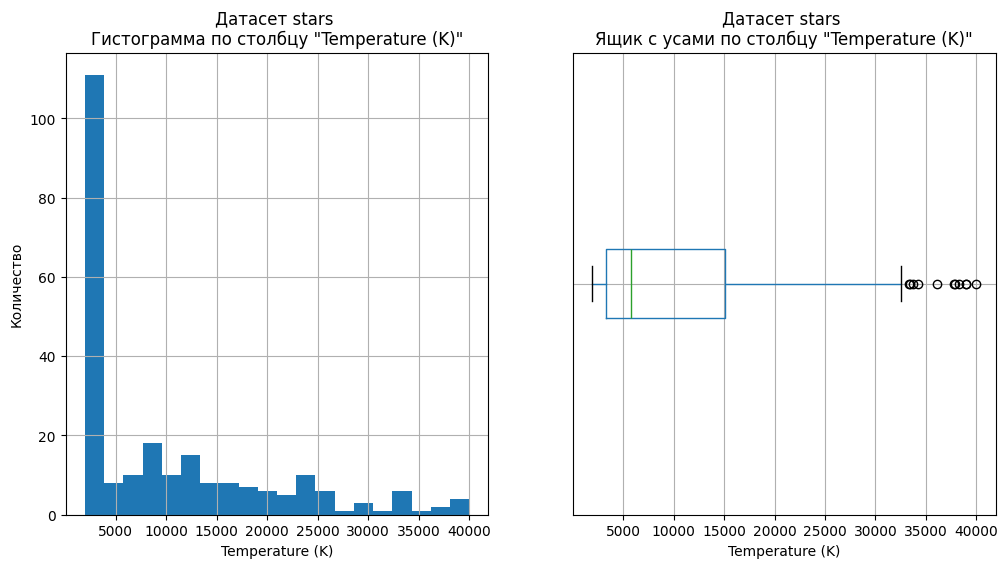

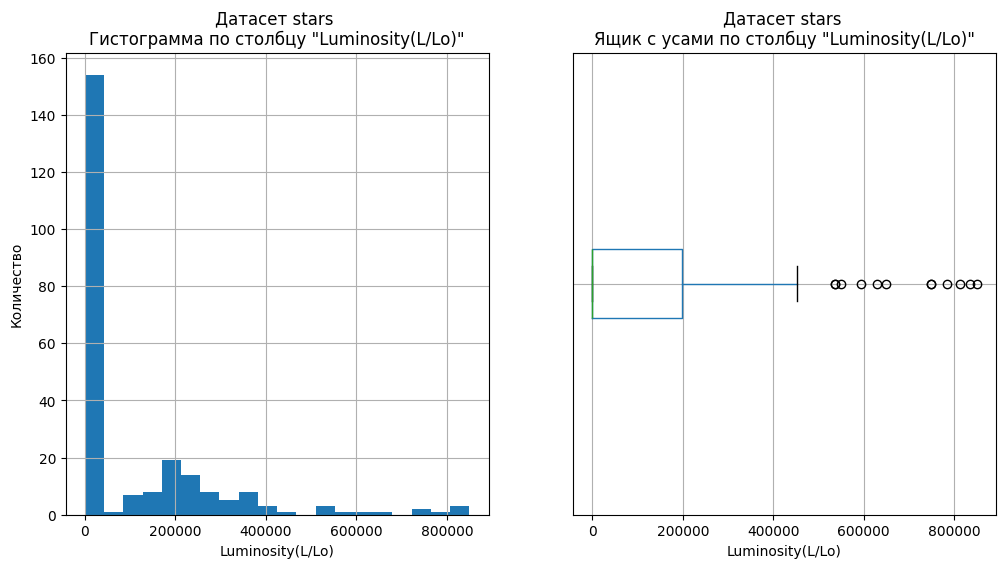

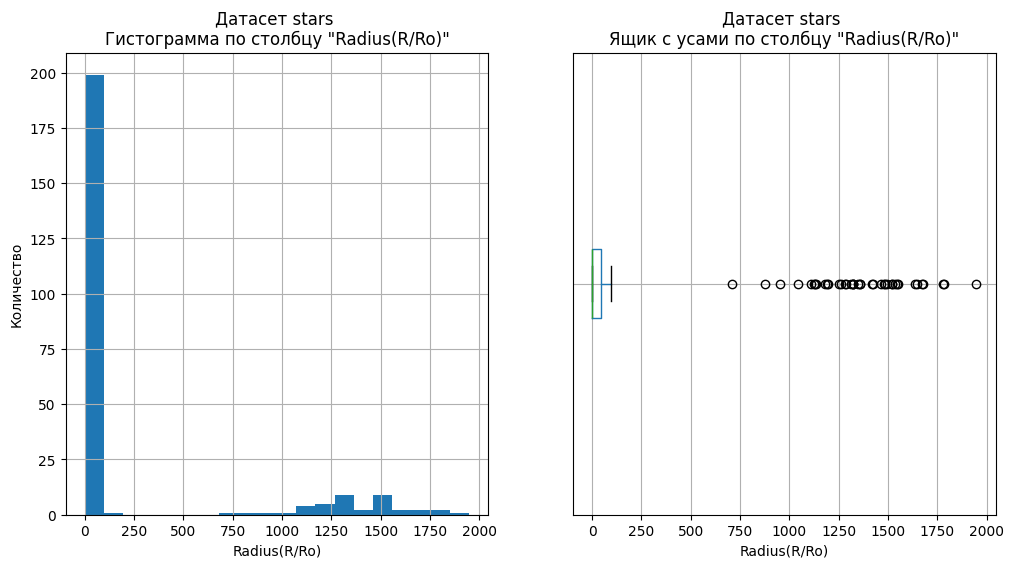

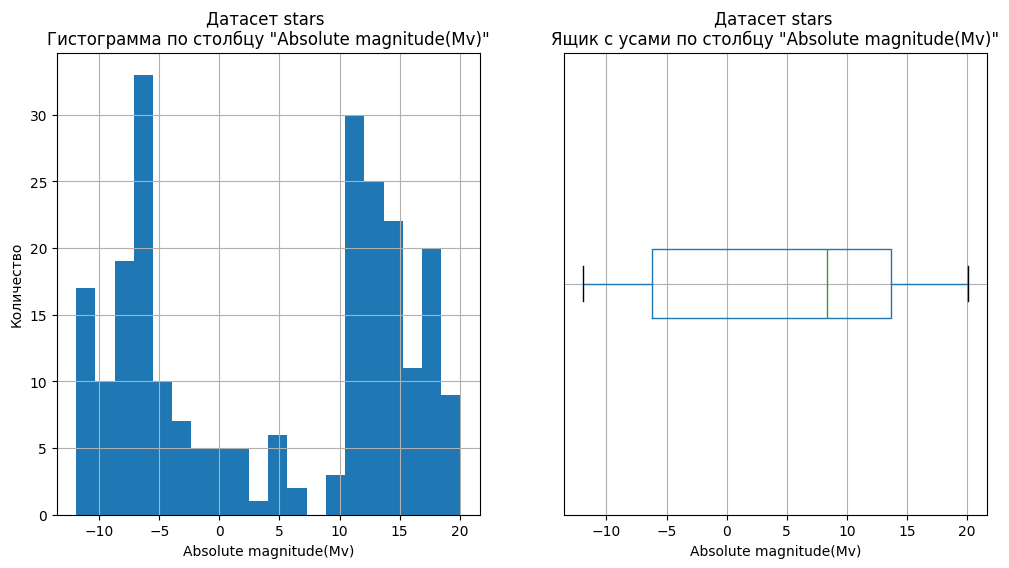

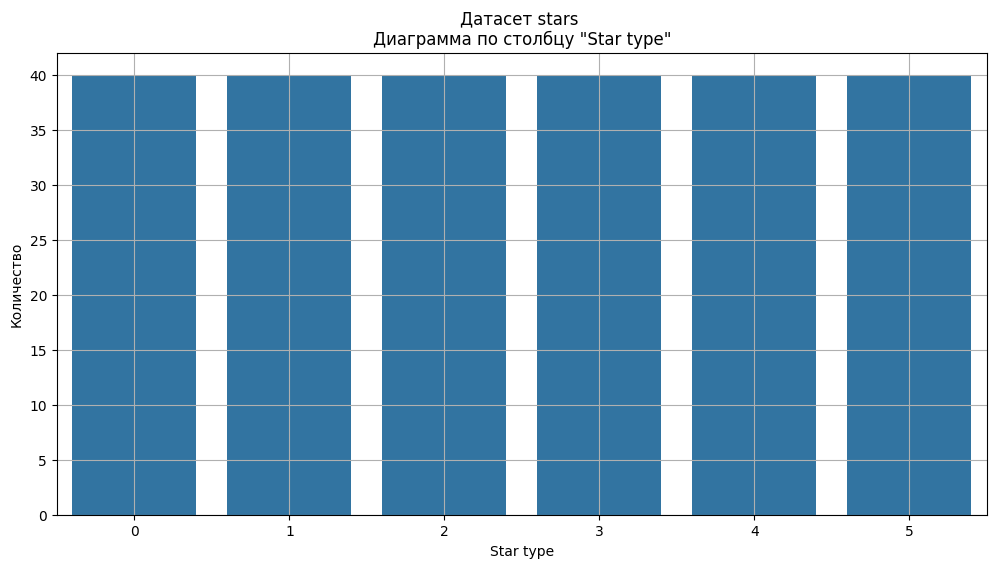

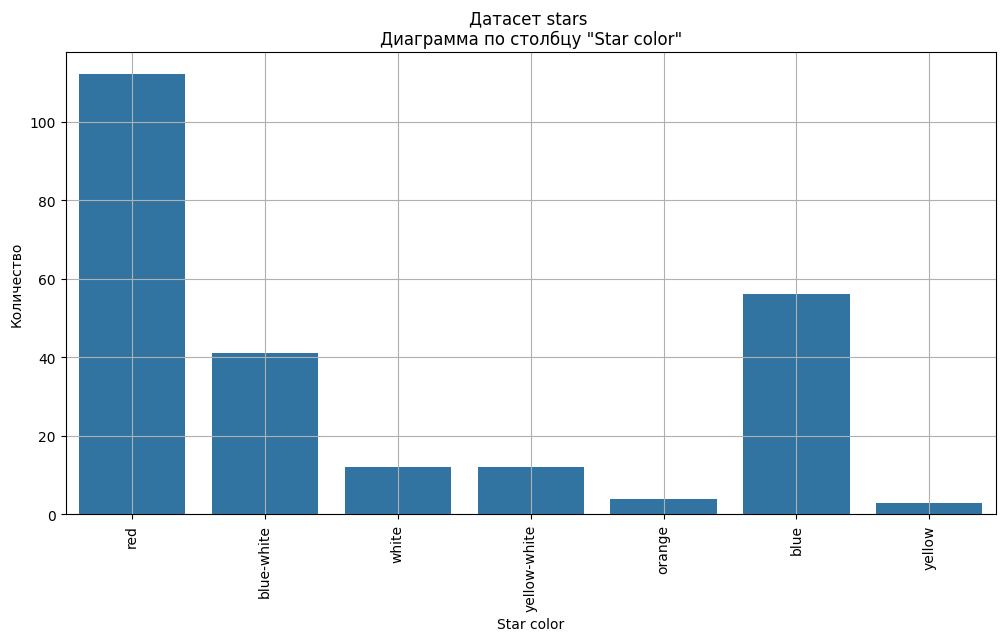

In [27]:
df_hist_dict(dict_1)

### Диаграммы рассеяния

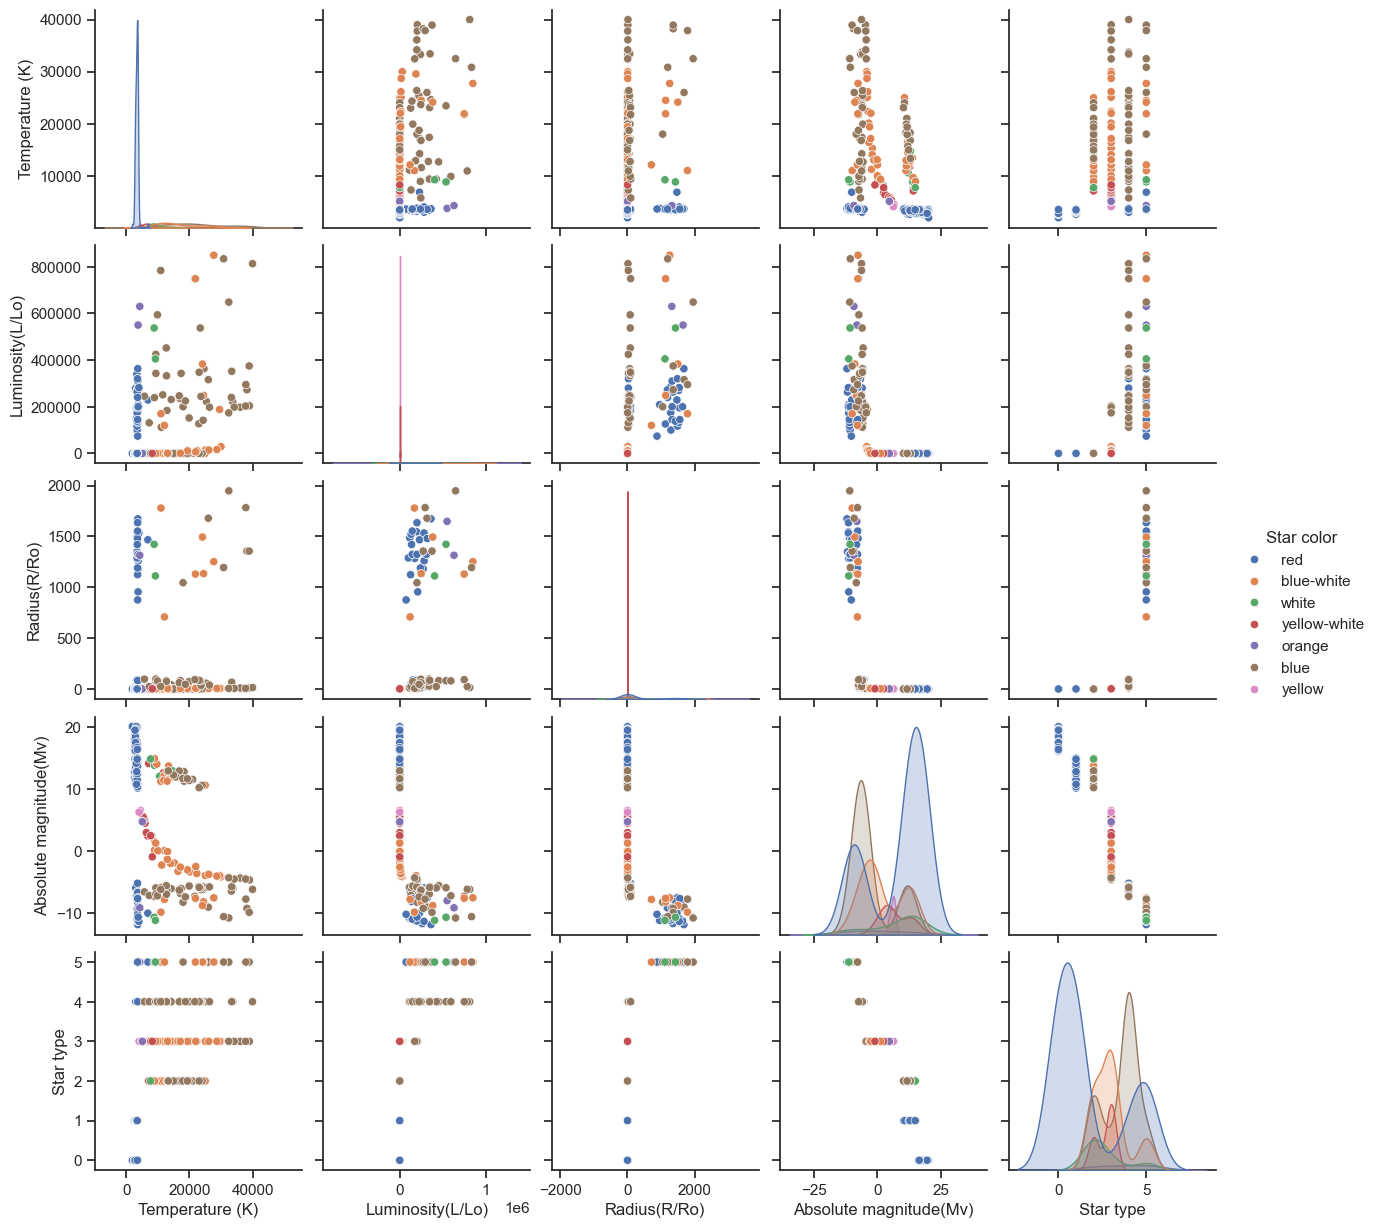

In [28]:
sns.set_theme(style="ticks")
sns.pairplot(dict_1['stars'], hue="Star color")

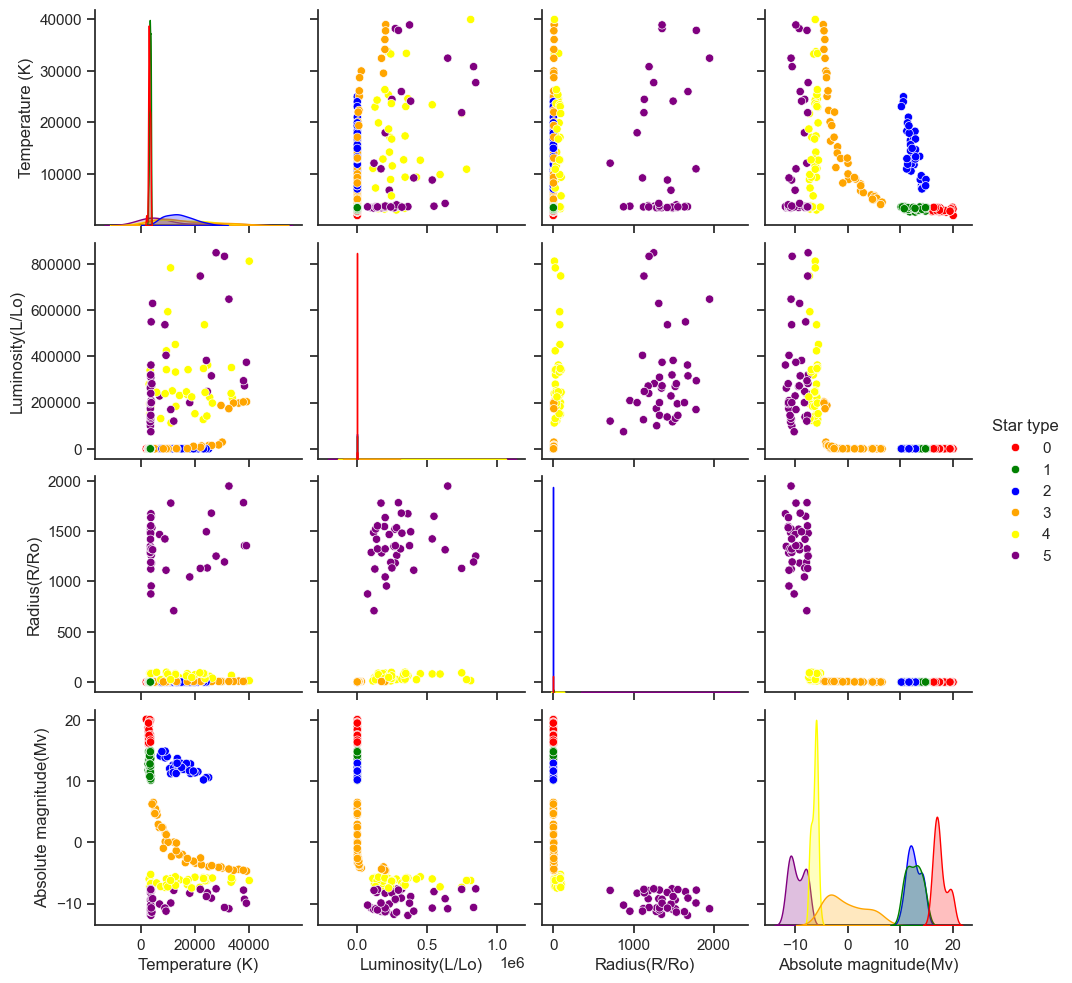

In [29]:
sns.set_theme(style='ticks')
sns.pairplot(dict_1['stars'], hue="Star type",palette=['red','green','blue','orange','yellow','purple'])

### Корреляционный анализ

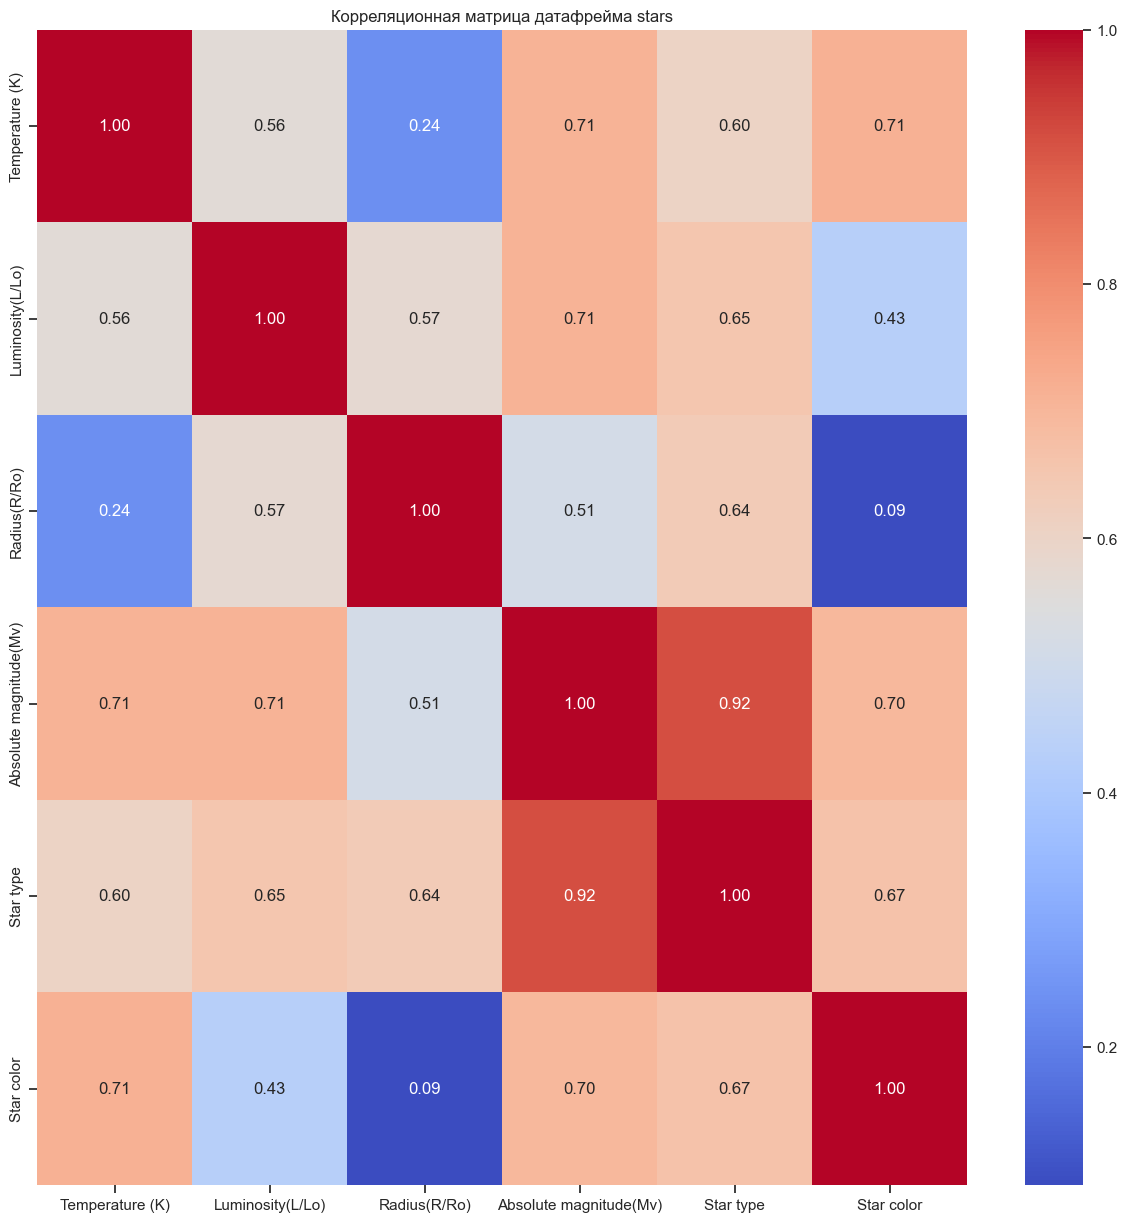

In [30]:
df_corr(dict_1, 
        continuous_features=['Temperature (K)',
							 'Luminosity(L/Lo)',
							 'Radius(R/Ro)',
                             'Absolute magnitude(Mv)']
                             )

### Промежуточный вывод

В результате исследовательского анализа не выявлено мультиколлинеарности признаков.
Только признаки "Тип звезды" и "Абсолютная магнитуда" имеют подобие линейной зависимости. Остальные признаки не показывают каких либо характерных зависимостей.

Так как данных мало, а для некоторых значений признаков экземпляров звёзд совсем мало, то может показаться наличие выбросов и аномалий. В данном случае данные являются действительными и в пределах реальных значений, поэтому не считаются выбросами и аномалиями.

Также видно значительный дисбаланс для признака "Цвет звезды", где у некоторых цветов по 3-4 экземпляра

Также явно выделяется тип звезд 5. Данные звезды имеют большой радиус, что сильно отличает их от других типов.

Также были выполнены следующие шаги:
- Обработаны неявные дубликаты

## Подготовка данных

In [31]:
X = dict_1['stars'].drop(columns=['Temperature (K)'], axis=1)
y = dict_1['stars']['Temperature (K)']

# разделение на тренировочную и тестовую выборки
X_train_original, X_test_original, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size = TEST_SIZE, 
                                                    random_state=RANDOM_STATE,
                                                    stratify = X['Star color']
                                                    )

X_train_original.shape, y_train.shape, X_test_original.shape, y_test.shape

((192, 5), (192,), (48, 5), (48,))

In [32]:
# создаём списки с названиями признаков
cat_columns = X_train_original.select_dtypes('object').columns.tolist()
num_columns = ['Luminosity(L/Lo)',
               'Radius(R/Ro)',
               'Absolute magnitude(Mv)'
               ]
ohe_columns = ['Star type',
               'Star color'
               ]


# ord_columns = ['',
#                ]
# num_columns = X_train_original.select_dtypes('number').columns.tolist()

In [33]:
# создаём пайплайны для подготовки признаков
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('ohe', OneHotEncoder(drop='first', 
                           handle_unknown='infrequent_if_exist',
                           sparse_output=False 
                           ))
    ]
    )

num_pipe = Pipeline(
    [('standardscaler', StandardScaler())
	]
    )

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('num', num_pipe, num_columns),
    ], 
    remainder='passthrough'
	)


In [34]:
X_train = data_preprocessor.fit_transform(X_train_original, y_train)
X_test = data_preprocessor.transform(X_test_original)

In [35]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train.values)
y_test = torch.FloatTensor(y_test.values)

### Промежуточный вывод
Данные для обучения и тестирования моделей подготовлены.

## Обучение моделей

### Построение простой модели нейронной сети — baseline

In [36]:
# Определение гиперпараметров
num_epochs = 3000
epoch_counter = 10
difficult = 1e-3

In [37]:
# Функция определения весов модели
def init_weights(layer):
    if type(layer) == nn.Linear: # Проверка, что слой – полносвязный
        nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(layer.bias)

#### Модель №1

In [41]:
n_neurons = [14, 9, 6, 3, 1]
net_layers = []

for i in range(1, len(n_neurons) - 1):
		net_layers.append(nn.Linear(n_neurons[i-1], n_neurons[i]))
		net_layers.append(nn.ReLU())

net_layers.append(nn.Linear(n_neurons[-2], n_neurons[-1]))

net = nn.Sequential(*net_layers)

net.apply(init_weights) 

optimizer = torch.optim.Adam(net.parameters(), lr=difficult)
loss = nn.MSELoss()


for epoch in range(num_epochs):
    optimizer.zero_grad()

    preds = net.forward(X_train).flatten()

    loss_value = loss(preds, y_train)

    loss_value.backward()

    optimizer.step()

    if epoch % (num_epochs / epoch_counter) == 0 or epoch == num_epochs - 1:
        net.eval()
        train_preds = net.forward(X_train)
        res_1 = root_mean_squared_error(y_train, train_preds.detach().cpu().numpy())
        test_preds_1 = net.forward(X_test)
        test_res_1 = root_mean_squared_error(y_test, test_preds_1.detach().cpu().numpy())
        print(f'RMSE на тренировочной = {res_1}')
        print(f'RMSE на тестовой = {test_res_1} \n')
        net.train()

RMSE на тренировочной = 14879.9423828125
RMSE на тестовой = 10938.7158203125 

RMSE на тренировочной = 14838.44921875
RMSE на тестовой = 10899.0830078125 

RMSE на тренировочной = 13753.322265625
RMSE на тестовой = 9954.3076171875 

RMSE на тренировочной = 10621.625
RMSE на тестовой = 7847.42041015625 

RMSE на тренировочной = 8385.9150390625
RMSE на тестовой = 7066.76171875 

RMSE на тренировочной = 7685.5771484375
RMSE на тестовой = 6618.08203125 

RMSE на тренировочной = 7360.9921875
RMSE на тестовой = 6313.41796875 

RMSE на тренировочной = 7110.32763671875
RMSE на тестовой = 6134.5283203125 

RMSE на тренировочной = 6878.07177734375
RMSE на тестовой = 5993.53125 

RMSE на тренировочной = 6637.73974609375
RMSE на тестовой = 5853.91259765625 

RMSE на тренировочной = 6382.8427734375
RMSE на тестовой = 5711.0791015625 



График на тестовой выборке
RMSE = 5711.0791015625


,predictions,facts,Номер
0,19311.318359,12749.0,1
1,10295.833984,3574.0,2
2,12722.835938,18000.0,3
3,13711.501953,19360.0,4
4,3178.708008,3212.0,5


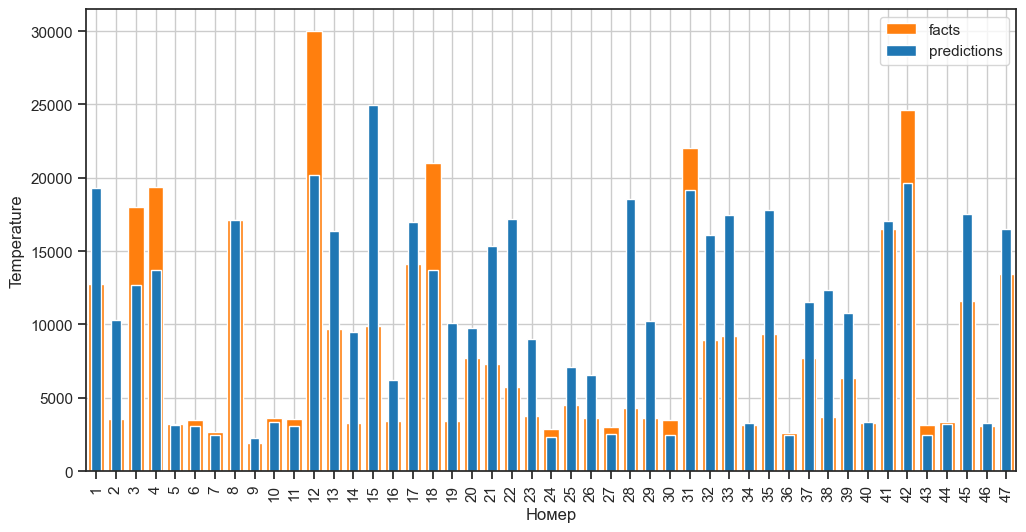

In [44]:
print('График на тестовой выборке')
plot_bars(test_preds_1, y_test, -1)

#### Модель №2

In [48]:
n_neurons = [14, 64, 32, 16, 1]
net_layers = []

for i in range(1, len(n_neurons) - 1):
		net_layers.append(nn.Linear(n_neurons[i-1], n_neurons[i]))
		net_layers.append(nn.ReLU())

net_layers.append(nn.Linear(n_neurons[-2], n_neurons[-1]))

net_2 = nn.Sequential(*net_layers)

net_2.apply(init_weights) 

optimizer_2 = torch.optim.Adam(net_2.parameters(), lr=difficult)
loss = nn.MSELoss()

for epoch in range(num_epochs):
    optimizer_2.zero_grad()

    preds = net_2(X_train).flatten()

    loss_value = loss(preds, y_train)
    # print(loss_value)

    loss_value.backward()

    optimizer_2.step()

    if epoch % (num_epochs / epoch_counter) == 0 or epoch == num_epochs - 1:
        net_2.eval()
        train_preds = net_2.forward(X_train)
        res_2 = root_mean_squared_error(y_train, train_preds.detach().cpu().numpy())
        test_preds_2 = net_2.forward(X_test)
        test_res_2 = root_mean_squared_error(y_test, test_preds_2.detach().cpu().numpy())
        print(f'RMSE на тренировочной = {res_2}')
        print(f'RMSE на тестовой = {test_res_2} \n')
        net_2.train()

RMSE на тренировочной = 14880.3359375
RMSE на тестовой = 10939.0478515625 

RMSE на тренировочной = 12511.328125
RMSE на тестовой = 8997.2763671875 

RMSE на тренировочной = 7570.62939453125
RMSE на тестовой = 6572.267578125 

RMSE на тренировочной = 6863.19873046875
RMSE на тестовой = 5977.439453125 

RMSE на тренировочной = 6207.896484375
RMSE на тестовой = 5583.9677734375 

RMSE на тренировочной = 5468.36572265625
RMSE на тестовой = 5168.24267578125 

RMSE на тренировочной = 4703.28125
RMSE на тестовой = 4847.97509765625 

RMSE на тренировочной = 4184.466796875
RMSE на тестовой = 4698.5 

RMSE на тренировочной = 3945.1591796875
RMSE на тестовой = 4671.8603515625 

RMSE на тренировочной = 3831.4892578125
RMSE на тестовой = 4696.93359375 

RMSE на тренировочной = 3747.846435546875
RMSE на тестовой = 4752.55029296875 



График на тестовой выборке
RMSE = 4752.55029296875


,predictions,facts,Номер
0,21354.904297,12749.0,1
1,2325.266113,3574.0,2
2,30148.880859,18000.0,3
3,19286.578125,19360.0,4
4,3225.051758,3212.0,5


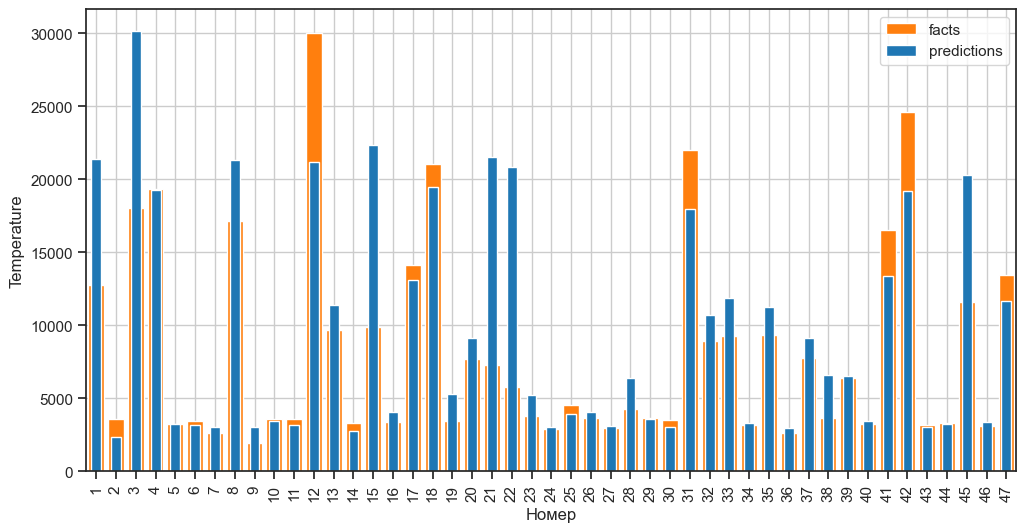

In [49]:
print('График на тестовой выборке')
plot_bars(test_preds_2, y_test, -1)

### Анализ метрик моделей №1 и №2

Модель №1 показывает рост метрик при обучении и не достигает порога переобучения. В следующей модели было испробовано другое количество скрытых нейронов. RMSE = 5711

Модель №2 показала результат метрики RMSE = 4752

Разница между моделями заключается в разном количестве нейронов в скрытых слоях. В модели №2 количество нейронов в скрытых слоя больше.

Согласно графикам обе модели более сильно ошибались в звездах с высокими температурами. Скорее всего связано с малым количеством данных звезд в датасете.

Обе модели не достигли цели по RMSE < 4500

### Улучшение сети

#### Подбор лучших параметров

In [51]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [52]:
def create_model(n_neurons, dropout_p, use_bn, use_dp):
    layers = []
    for i in range(1, len(n_neurons)-1):
        layers.append(nn.Linear(n_neurons[i-1], n_neurons[i]))
        if i%2 ==0 and use_bn:
            layers.append(nn.BatchNorm1d(n_neurons[i]))
        layers.append(nn.ReLU())
        if i%2 !=0 and use_dp:
            layers.append(nn.Dropout(dropout_p))
    layers.append(nn.Linear(n_neurons[-2], n_neurons[-1]))
    net = nn.Sequential(*layers)
    net.apply(init_weights)
    return net

In [53]:
def objective(trial):
    # Гиперпараметры
    num_epochs = trial.suggest_categorical('num_epochs', [1000, 2000, 3000, 4000])
    lr = trial.suggest_categorical('lr', [1e-4, 1e-3, 1e-2])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])
    use_bn = True
    use_dp = True
    dropout_p = trial.suggest_categorical('dropout_p', [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]) if use_dp else 0.1
    
    # Создание DataLoader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Модель
    n_neurons = [14, 64, 32, 16, 1]
    model = create_model(n_neurons, dropout_p, use_bn, use_dp)
    model.apply(init_weights)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    # Обучение (эпохи)
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch).flatten()
            loss = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
    
    # Валидация
    model.eval()
    test_preds_list = []
    test_true_list = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch).flatten()
            test_preds_list.append(preds)
            test_true_list.append(y_batch)
    test_preds = torch.cat(test_preds_list)
    test_true = torch.cat(test_true_list)
    test_rmse = torch.sqrt(loss_fn(test_preds, test_true)).item()
    
    return test_rmse

In [47]:
%%time
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Лучшие параметры:", study.best_params)
print("Лучший RMSE на валидации:", study.best_value)

[I 2026-04-23 13:10:25,113] A new study created in memory with name: no-name-5a92cc26-d997-4774-a92d-c2115775e466
[I 2026-04-23 13:11:45,180] Trial 0 finished with value: 4489.89501953125 and parameters: {'num_epochs': 2000, 'lr': 0.001, 'batch_size': 16, 'dropout_p': 0.1}. Best is trial 0 with value: 4489.89501953125.
[I 2026-04-23 13:12:22,059] Trial 1 finished with value: 4212.3955078125 and parameters: {'num_epochs': 3000, 'lr': 0.01, 'batch_size': 64, 'dropout_p': 0.4}. Best is trial 1 with value: 4212.3955078125.
[I 2026-04-23 13:13:01,073] Trial 2 finished with value: 4226.3720703125 and parameters: {'num_epochs': 1000, 'lr': 0.001, 'batch_size': 16, 'dropout_p': 0.1}. Best is trial 1 with value: 4212.3955078125.
[I 2026-04-23 13:14:26,004] Trial 3 finished with value: 4187.68896484375 and parameters: {'num_epochs': 4000, 'lr': 0.001, 'batch_size': 32, 'dropout_p': 0.8}. Best is trial 3 with value: 4187.68896484375.
[I 2026-04-23 13:15:05,453] Trial 4 finished with value: 4011.3

Лучшие параметры: {'num_epochs': 4000, 'lr': 0.001, 'batch_size': 32, 'dropout_p': 0.5}
Лучший RMSE на валидации: 3778.40869140625
CPU times: total: 7h 48min 22s
Wall time: 1h 57min 41s


#### Модель №3

In [54]:
# Гиперпараметры
num_epochs = 4000
lr = 1e-3
batch_size = 32
use_bn = True
use_dp = True
dropout_p = 0.5

n_neurons = [14, 64, 32, 16, 1]
net_3 = create_model(n_neurons, dropout_p, use_bn, use_dp)
net_3.apply(init_weights)

# Создание DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

optimizer_3 = torch.optim.Adam(net_3.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Обучение (эпохи)
for epoch in range(num_epochs):
	net_3.train()
	total_loss = 0.0

	for X_batch, y_batch in train_loader:
		optimizer_3.zero_grad()
		preds = net_3(X_batch).flatten()
		loss = loss_fn(preds, y_batch)
		loss.backward()
		optimizer_3.step()
		total_loss += loss.item()

	if epoch % (num_epochs / epoch_counter) == 0 or epoch == num_epochs - 1:
		net_3.eval()
		train_preds = net_3.forward(X_train)
		res_3 = root_mean_squared_error(y_train, train_preds.detach().cpu().numpy())
		test_preds_3 = net_3.forward(X_test)
		test_res_3 = root_mean_squared_error(y_test, test_preds_3.detach().cpu().numpy())
		print(f'RMSE на тренировочной = {res_3}')
		print(f'RMSE на тестовой = {test_res_3} \n')

RMSE на тренировочной = 14879.3115234375
RMSE на тестовой = 10938.3271484375 

RMSE на тренировочной = 4330.88427734375
RMSE на тестовой = 4037.93212890625 

RMSE на тренировочной = 3856.11865234375
RMSE на тестовой = 3910.880126953125 

RMSE на тренировочной = 3784.489501953125
RMSE на тестовой = 4035.047119140625 

RMSE на тренировочной = 3684.5
RMSE на тестовой = 4003.63330078125 

RMSE на тренировочной = 3755.502685546875
RMSE на тестовой = 3985.287841796875 

RMSE на тренировочной = 3731.677734375
RMSE на тестовой = 3835.37060546875 

RMSE на тренировочной = 3670.600341796875
RMSE на тестовой = 4018.654052734375 

RMSE на тренировочной = 3679.02001953125
RMSE на тестовой = 4020.74267578125 

RMSE на тренировочной = 3671.78466796875
RMSE на тестовой = 4079.887939453125 

RMSE на тренировочной = 3722.061767578125
RMSE на тестовой = 4029.01416015625 



График на тестовой выборке
RMSE = 4029.01416015625


,predictions,facts,Номер
0,17403.248047,12749.0,1
1,3338.207520,3574.0,2
2,30669.949219,18000.0,3
3,16435.400391,19360.0,4
4,2337.141602,3212.0,5


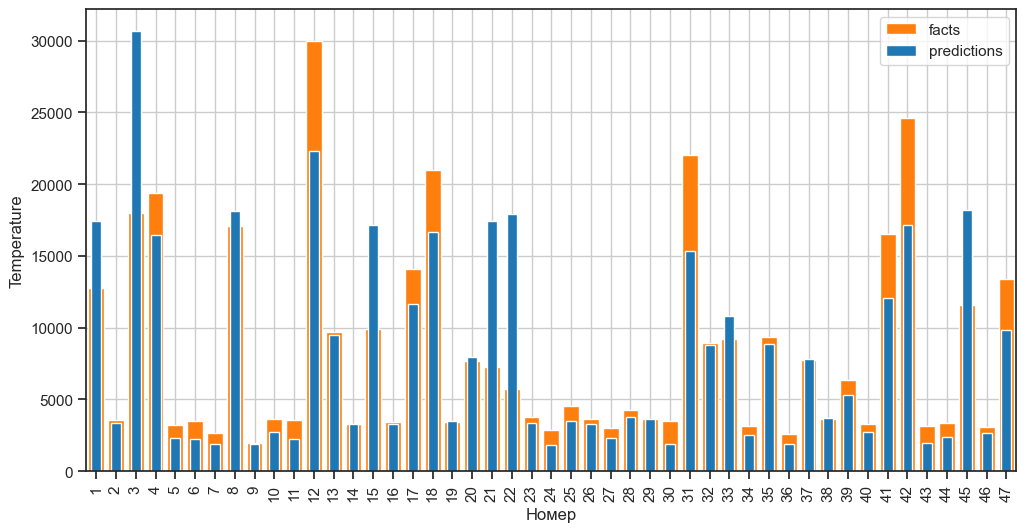

In [58]:
net_3.eval()
test_preds_3 = net_3.forward(X_test)
test_res_3 = root_mean_squared_error(y_test, test_preds_3.detach().cpu().numpy())
print('График на тестовой выборке')
plot_bars(test_preds_3, y_test, -1)

##### Анализ метрики модели 3

Согласно графику можно понять что расхождение значений для звезд с высокой температурой стало не таким ссильным как для первых двух моделей, но при этом увеличилось расхождение для звезд с относительно малой температурой.

При этом общая RMSE уменьшилась за счет улучшения предсказания на звездах с высокой температурой

### Анализ метрик всех моделей

In [56]:
df_metrics = pd.DataFrame([res_1,res_2,res_3], columns=['RMSE на тренировочной выборке'],index=[1,2,3]).round(2)
df_metrics

,RMSE на тренировочной выборке
1,6382.84
2,3747.85
3,3722.06


Согласно метрикам RMSE на тренировочных данных, модель №4 имеет лучший результат 3571

In [57]:
df_metrics = pd.DataFrame([test_res_1,test_res_2,test_res_3], 
                          columns=['RMSE на тестовой выборке'],
                          index=[1,2,3]).round(2)
df_metrics

,RMSE на тестовой выборке
1,5711.08
2,4752.55
3,4029.01


## Вывод

В ходе обучения моделей были подготовлены 4 модели. 

На тренировочных данных:
- Модель №1 показала результат метрики RMSE = 6382
- Модель №2 показала результат метрики RMSE = 3747
- Модель №3 показала результат метрики RMSE = 3722

На тестовых данных:
- Модель №1 показала результат метрики RMSE = 5711
- Модель №2 показала результат метрики RMSE = 4752
- Модель №3 показала результат метрики RMSE = 4029

Лучше всего показала себя базовая модель №3 с результатом RMSE на тестовой 4029. 
Задача проекта достич результата RMSE менее 4500 достигнута
